In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image

C:\Users\yanic\miniconda3\envs\pytorch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"
try:
    image_processor = AutoImageProcessor.from_pretrained(model_name)
    model = AutoModelForSemanticSegmentation.from_pretrained(model_name)
    print(f"Successfully loaded model: {model_name}")
except Exception as e:
    print(f"FATAL ERROR during model loading: {e}")
    exit()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
C:\Users\yanic\miniconda3\envs\pytorch_env\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Successfully loaded model: nvidia/segformer-b0-finetuned-ade-512-512


In [11]:
image_path = "../example_data/nieuw.jpg"
try:
    image = Image.open(image_path).convert("RGB")
except FileNotFoundError:
    print("Error: Image file not found at the specified path.")
    exit()

inputs = image_processor(images=image, return_tensors="pt")

In [12]:
with torch.no_grad():
    outputs = model(**inputs)

# Post-processing & Upsampling
logits = outputs.logits

upsampled_logits = F.interpolate(
    logits,
    size=image.size[::-1], # (height, width)
    mode="bilinear",
    align_corners=False,
)

pred_seg = torch.argmax(upsampled_logits, dim=1).squeeze().cpu().numpy()

In [13]:
model.config.id2label

{0: 'wall',
 1: 'building',
 2: 'sky',
 3: 'floor',
 4: 'tree',
 5: 'ceiling',
 6: 'road',
 7: 'bed ',
 8: 'windowpane',
 9: 'grass',
 10: 'cabinet',
 11: 'sidewalk',
 12: 'person',
 13: 'earth',
 14: 'door',
 15: 'table',
 16: 'mountain',
 17: 'plant',
 18: 'curtain',
 19: 'chair',
 20: 'car',
 21: 'water',
 22: 'painting',
 23: 'sofa',
 24: 'shelf',
 25: 'house',
 26: 'sea',
 27: 'mirror',
 28: 'rug',
 29: 'field',
 30: 'armchair',
 31: 'seat',
 32: 'fence',
 33: 'desk',
 34: 'rock',
 35: 'wardrobe',
 36: 'lamp',
 37: 'bathtub',
 38: 'railing',
 39: 'cushion',
 40: 'base',
 41: 'box',
 42: 'column',
 43: 'signboard',
 44: 'chest of drawers',
 45: 'counter',
 46: 'sand',
 47: 'sink',
 48: 'skyscraper',
 49: 'fireplace',
 50: 'refrigerator',
 51: 'grandstand',
 52: 'path',
 53: 'stairs',
 54: 'runway',
 55: 'case',
 56: 'pool table',
 57: 'pillow',
 58: 'screen door',
 59: 'stairway',
 60: 'river',
 61: 'bridge',
 62: 'bookcase',
 63: 'blind',
 64: 'coffee table',
 65: 'toilet',
 66: '

In [14]:
label_map = model.config.id2label
CLOUD_MASK_ID = 2
print(f"\nUsing assumed 'sky' class ID: {CLOUD_MASK_ID} ({label_map.get(CLOUD_MASK_ID, 'Unknown/Check Label')})")


Using assumed 'sky' class ID: 2 (sky)


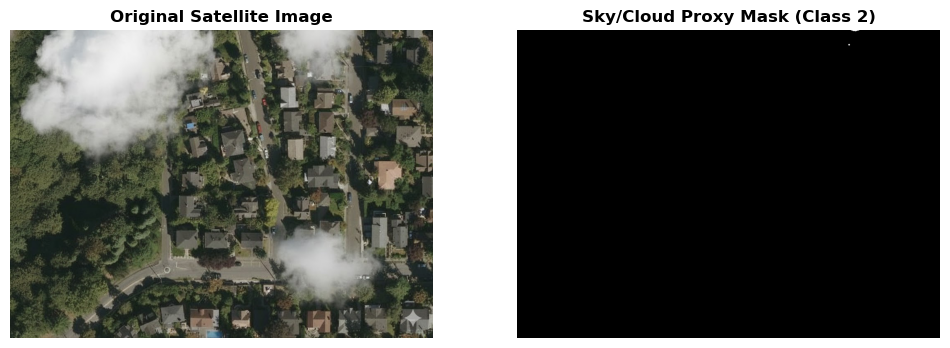

In [15]:
cloud_mask = (pred_seg == CLOUD_MASK_ID).astype(np.uint8)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Original Satellite Image")
ax[0].axis('off')

ax[1].imshow(cloud_mask, cmap='gray')
ax[1].set_title(f"Sky/Cloud Proxy Mask (Class {CLOUD_MASK_ID})")
ax[1].axis('off')

plt.show()

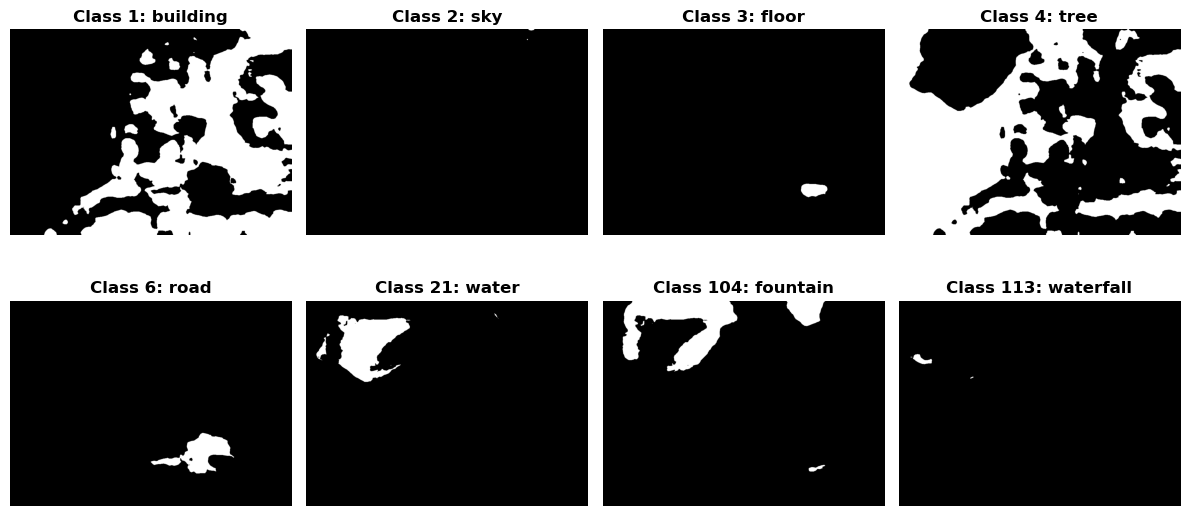

In [16]:
# plot every label mask
unique_labels = np.unique(pred_seg)
num_labels = len(unique_labels)
cols = 4
rows = (num_labels + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()
for i, label_id in enumerate(unique_labels):
    label_mask = (pred_seg == label_id).astype(np.uint8)
    axes[i].imshow(label_mask, cmap='gray')
    axes[i].set_title(f"Class {label_id}: {label_map.get(label_id, 'Unknown')}")
    axes[i].axis('off')
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

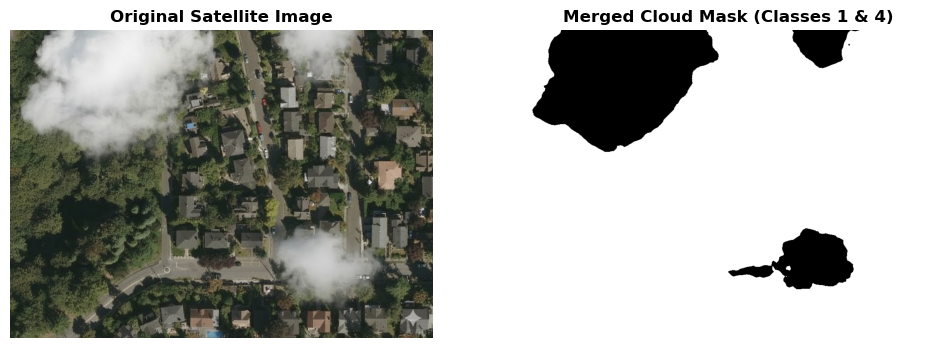

In [20]:
# merge mask 1 and mask 4 as clouds
merged_cloud_mask = ((pred_seg == 1) | (pred_seg == 4)).astype(np.uint8)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Original Satellite Image")
ax[0].axis('off')
ax[1].imshow(merged_cloud_mask, cmap='gray')
ax[1].set_title("Merged Cloud Mask")
ax[1].axis('off')
plt.show()

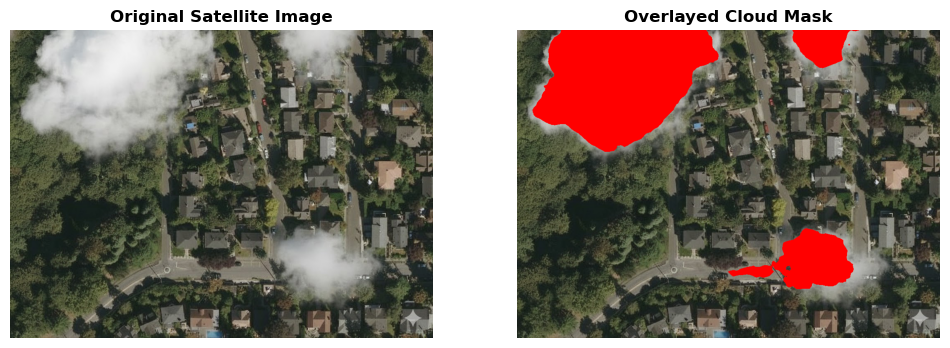

In [22]:
# overlay the merged mask on the original image
overlay = image.copy()
overlay_np = np.array(overlay)
overlay_np[merged_cloud_mask == 0] = [255, 0, 0]  # Red overlay for clouds
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Original Satellite Image")
ax[0].axis('off')
ax[1].imshow(overlay_np)
ax[1].set_title("Overlayed Cloud Mask")
ax[1].axis('off')
plt.show()